Kexin Dong

Dec 15, 2025

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

In [3]:
LIB = pd.read_csv('FINAL_focused_library_PAM.csv', index_col=0)
LIB_OG = pd.read_csv('MBESv2_CORRECTED_PAM.csv', index_col=0)

In [5]:
LFC_ABE = pd.read_csv('ABE_LFC_FDR_df.csv')
LFC_CBE = pd.read_csv('CBE_LFC_FDR_df.csv')
LFC_ABE_OG = pd.read_csv('ABE_LFC_FDR_df_og.csv')
LFC_CBE_OG = pd.read_csv('CBE_LFC_FDR_df_og.csv')

In [ ]:
 #calculating z-scores for standardization of comparison
samples = ['bm', 'd15', 'd5', 'men', 'spleen']
samples_og = ['bonemarrow','meninges','d15','d5','spleen']

def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

LFC_ABE = z_score(LFC_ABE, samples)
LFC_CBE = z_score(LFC_CBE, samples)
LFC_ABE_OG = z_score(LFC_ABE_OG, samples_og)
LFC_CBE_OG = z_score(LFC_CBE_OG, samples_og)

In [19]:
print(list(LFC_CBE_OG.columns))

['gRNA_id', 'Gene', 'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'LFC_avg_spleen', 'LFC_median_spleen', 'Input_median', 'bonemarrow1', 'bonemarrow2', 'bonemarrow3', 'bonemarrow4', 'bonemarrow5', 'bonemarrow6', 'bonemarrow7', 'bonemarrow8', 'bonemarrow9', 'bonemarrow10', 'LFC_avg_bonemarrow', 'LFC_median_bonemarrow', 'meninges1', 'meninges2', 'meninges3', 'meninges4', 'meninges5', 'meninges6', 'meninges7', 'meninges8', 'meninges9', 'meninges10', 'LFC_avg_meninges', 'LFC_median_meninges', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'plasmidlib', 'LFC_avg_plasmid_lib', 'LFC_median_plasmid_lib', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5_fishers', 'p_low_unadjusted_d5_fishe

In [26]:
samples_og = ['bonemarrow', 'd15', 'd5',  'meninges','spleen']

In [27]:
names_LFC_median = [f'LFC_median_{x}' for x in samples]
names_z_score = [f'z_score_{x}' for x in samples]
names_z_score_og = [f'z_score_{x}' for x in samples_og]

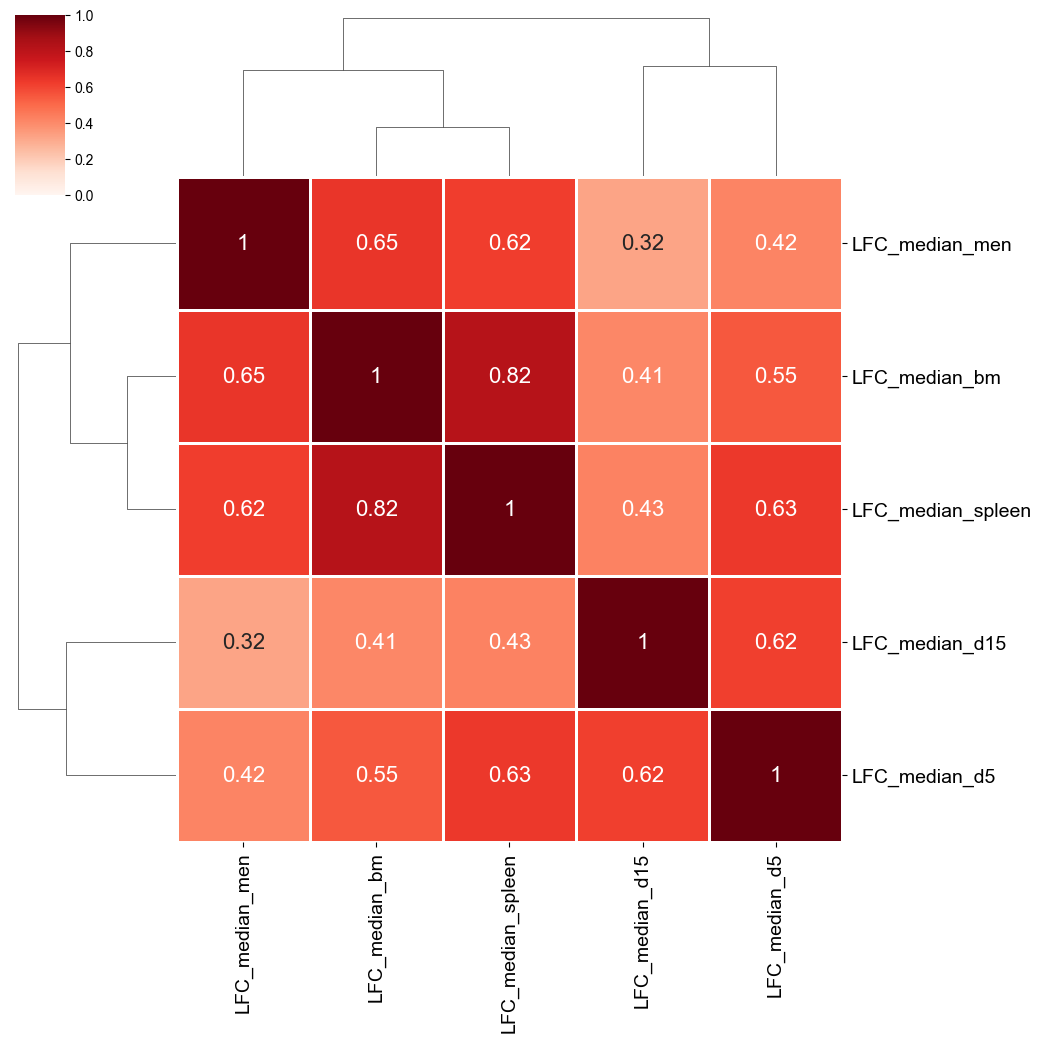

In [ ]:
g = sns.clustermap(LFC_ABE[names_LFC_median].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
g.savefig('figures/ABE_LFC_pearson.pdf')

In [13]:
LIB = pd.read_csv('FINAL_focused_library_PAM.csv', index_col=0)
LIB_OG = pd.read_csv('MBESv2_CORRECTED_PAM.csv', index_col=0)
list_NGG_PAM = [f'{x}GG' for x in ['A','T','G','C']]
guides_NGG_CBE_focused = list(LIB[ (LIB['Editor']=='CBE') & (LIB['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
guides_NGG_CBE_og = list(LIB_OG[ (LIB_OG['Editor']=='CBE') & (LIB_OG['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])

In [14]:
LFC_CBE_NGG = LFC_CBE[LFC_CBE['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)

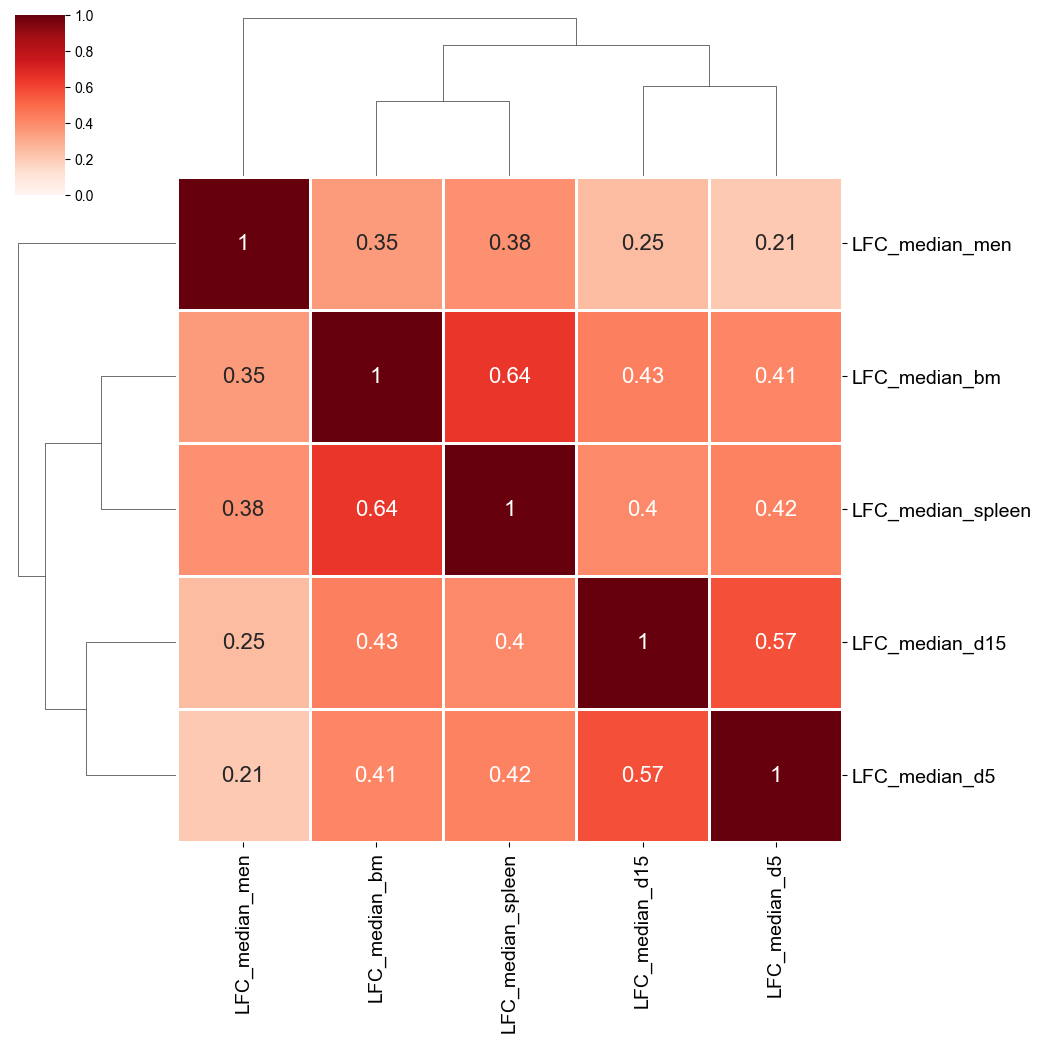

In [16]:
g = sns.clustermap(LFC_CBE_NGG[names_LFC_median].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
g.savefig('figures/CBE_LFC_pearson.pdf')

In [24]:
samples

['bm', 'd15', 'd5', 'men', 'spleen']

In [38]:
LFC_ABE['classification'].unique()

array(['targeting guide', 'non-targeting control',
       'safe-targeting control'], dtype=object)

In [41]:
ABE_targ = LFC_ABE[LFC_ABE['classification'].isin(['targeting guide'])]
df_ABE = ABE_targ[['gRNA_id']+names_z_score]
df_ABE.columns = ['gRNA_id']+[f'focused_{x}' for x in samples]
df_ABE_og = LFC_ABE_OG[['gRNA_id']+names_z_score_og]
df_ABE_og.columns = ['gRNA_id']+[f'og_{x}' for x in samples]
df_ABE = pd.merge(df_ABE, df_ABE_og, on = 'gRNA_id')
len(df_ABE)

170

In [42]:
df_CBE = LFC_CBE_NGG[['gRNA_id']+names_z_score]
df_CBE.columns = ['gRNA_id']+[f'focused_{x}' for x in samples]
df_CBE_og = LFC_CBE_OG[['gRNA_id']+names_z_score_og]
df_CBE_og.columns = ['gRNA_id']+[f'og_{x}' for x in samples]
df_CBE = pd.merge(df_CBE, df_CBE_og, on = 'gRNA_id')
len(df_CBE)

202

In [43]:
df_CBE

,gRNA_id,focused_bm,focused_d15,focused_d5,focused_men,focused_spleen,og_bm,og_d15,og_d5,og_men,og_spleen
0,gRNA_19,1.274386,-0.580272,1.618694,0.451196,1.018720,1.436326,0.032999,1.003703,0.616789,1.185327
1,gRNA_289,-1.547102,-0.054106,0.068440,-1.842673,0.407363,-1.817588,-1.703526,-0.911843,-1.207419,-2.081810
2,gRNA_303,0.716088,-0.203674,0.892858,-1.921749,0.437363,2.609554,2.407552,2.047355,1.095034,2.203657
3,gRNA_382,0.475292,0.716504,0.385675,0.910281,0.950236,-0.455473,0.841250,0.929218,0.360570,-0.417446
4,gRNA_525,0.697677,1.250422,0.484680,1.397230,0.678888,-0.246697,-0.025751,-0.428583,0.176426,-0.817325
...,...,...,...,...,...,...,...,...,...,...,...
197,gRNA_12833,0.212921,0.782076,0.864959,0.451972,0.486913,0.957279,1.543886,0.394949,0.176614,1.108043
198,gRNA_12838,-0.032431,0.711634,0.441738,-0.803159,-0.290318,0.888935,1.098941,0.529977,0.139606,1.086225
199,gRNA_12870,1.188673,-0.339668,-0.682079,-0.180627,-0.314426,-3.278895,-1.626106,-0.893878,-1.477843,-1.424370
200,gRNA_12881,-0.520581,1.458512,1.124547,2.075655,0.372537,-1.435228,0.687042,-0.151784,-0.963592,-1.374757


ABE
Spearman Correlation Coefficient: 0.3807
3.0234037346773315e-07
Pearson Correlation Coefficient: 0.4896
1.2426578740864967e-11
CBE
Spearman Correlation Coefficient: 0.2132
0.0023114275757639634
Pearson Correlation Coefficient: 0.2576
0.00021474238285415655
ABE
Spearman Correlation Coefficient: 0.2370
0.0018630663501660147
Pearson Correlation Coefficient: 0.3201
2.0879695812819375e-05
CBE
Spearman Correlation Coefficient: 0.0047
0.9466731414247915
Pearson Correlation Coefficient: -0.0629
0.3738374260288446
ABE
Spearman Correlation Coefficient: 0.0897
0.24470881462012406
Pearson Correlation Coefficient: 0.1097
0.15431006000426084
CBE
Spearman Correlation Coefficient: -0.0238
0.7363796610176341
Pearson Correlation Coefficient: 0.0058
0.9345917523692139
ABE
Spearman Correlation Coefficient: 0.2333
0.002195662237976843
Pearson Correlation Coefficient: 0.3043
5.461050976464284e-05
CBE
Spearman Correlation Coefficient: -0.0482
0.4957177501151485
Pearson Correlation Coefficient: -0.0288
0.

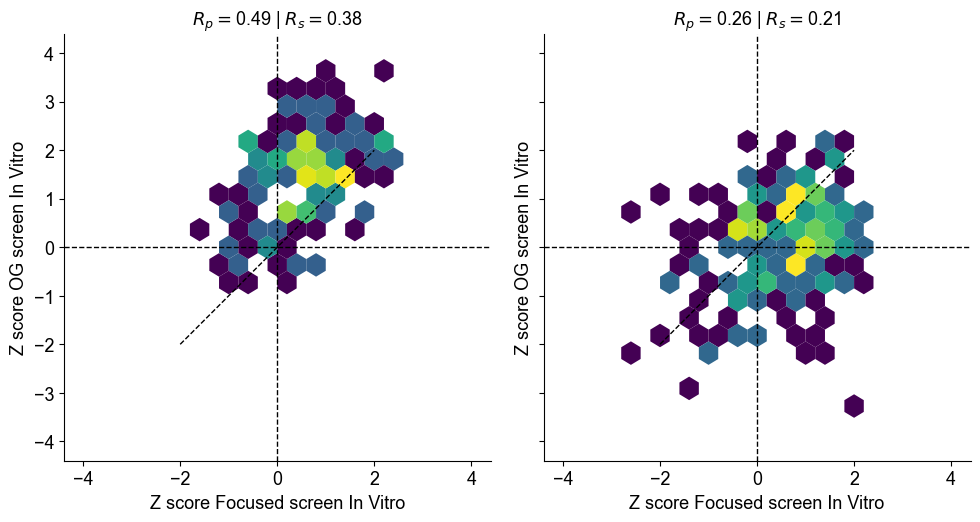

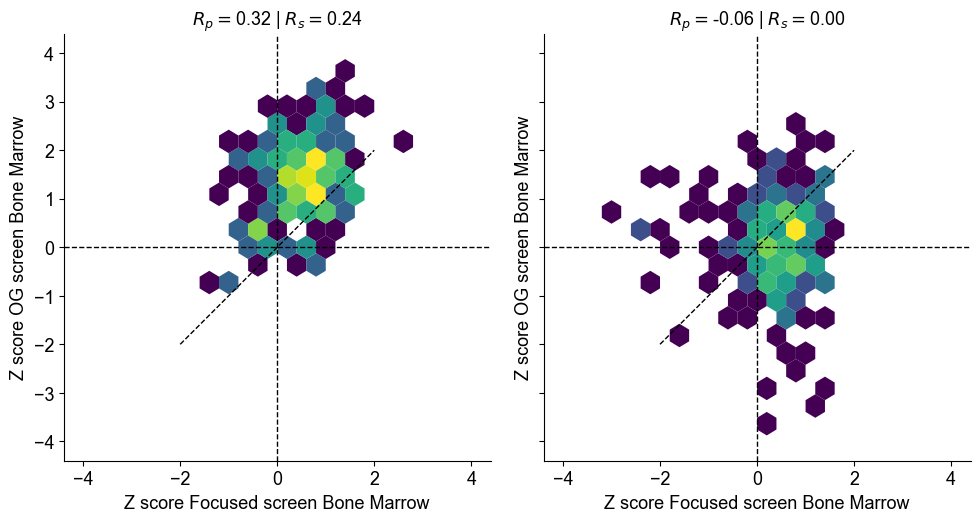

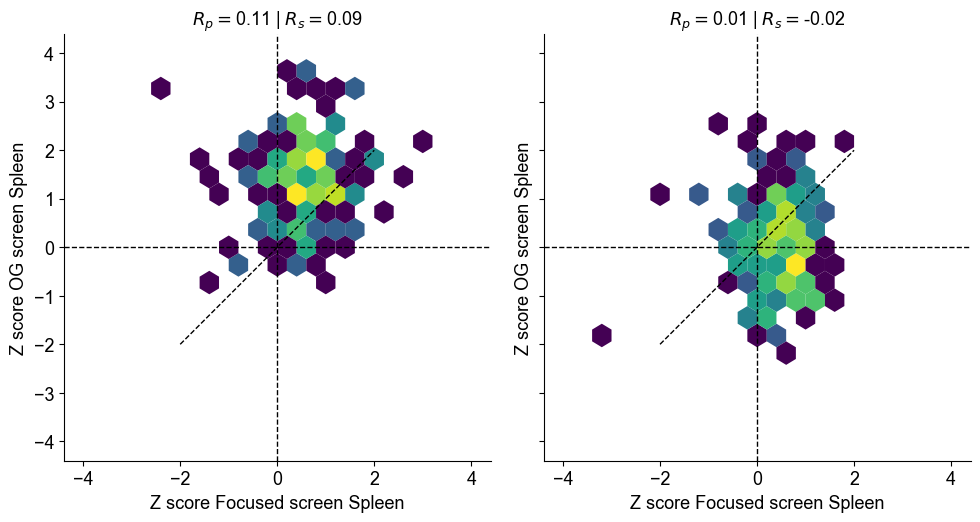

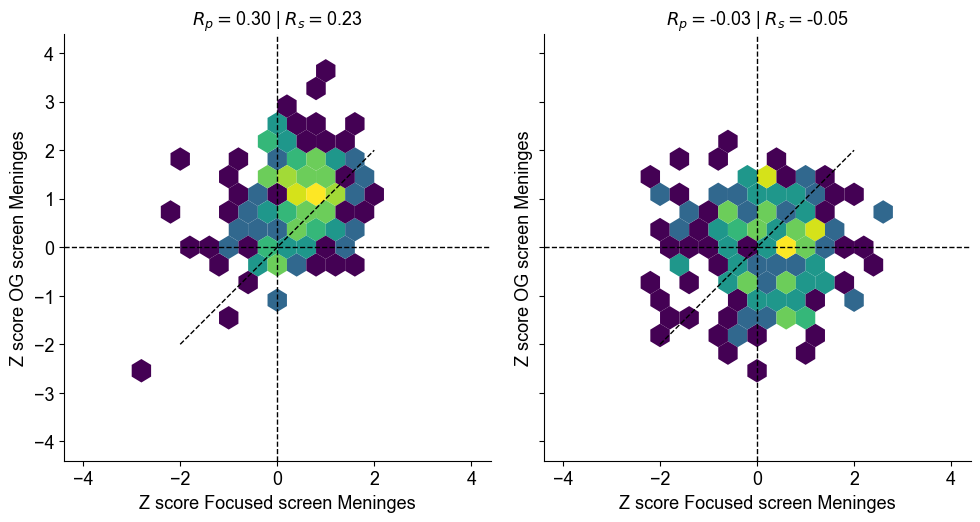

In [64]:
name_dict = dict(zip(['d15','bm','spleen','men'],[
    'In Vitro',
    'Bone Marrow',
    'Spleen','Meninges'
]))
for tissue in ['d15','bm','spleen','men']:
    fig, ax = plt.subplots(1,2, figsize = (10,5), sharey=True, sharex=True)
    for i, (df, name) in enumerate(zip([df_ABE, df_CBE], ['ABE','CBE'])):
        ax[i].set_aspect('equal')
        print(name)
        corr_spearman, p_value_spearman = scipy.stats.spearmanr(df[f'focused_{tissue}'], df[f'og_{tissue}'])
        print("Spearman Correlation Coefficient: {:.4f}".format(corr_spearman))
        print(p_value_spearman)
        corr_pearson, p_value_pearson = scipy.stats.pearsonr(df[f'focused_{tissue}'], df[f'og_{tissue}'])
        print("Pearson Correlation Coefficient: {:.4f}".format(corr_pearson))
        print(p_value_pearson)
        pear = "{:.2f}".format(corr_pearson)
        spear = "{:.2f}".format(corr_spearman)
        ax[i].hexbin(df[f'focused_{tissue}'], df[f'og_{tissue}'],  bins='log',gridsize=20, linewidth=0, extent = (-4, 4, -4, 4))
        ax[i].set_title('$R_{p} = $' + f'{pear}' + ' | $R_{s} = $' + f'{spear}', fontsize=13)
        ax[i].plot([-2,2],[-2,2], linestyle='dashed', color='black', linewidth=1)
        ax[i].axhline(y=0, linestyle='dashed', color='black', linewidth=1)
        ax[i].axvline(x=0, linestyle='dashed', color='black', linewidth=1)
        ax[i].set_xlabel(f'Z score Focused screen {name_dict[tissue]}', fontsize=13)
        ax[i].set_ylabel(f'Z score OG screen {name_dict[tissue]}', fontsize=13)
        ax[i].spines[['top', 'right']].set_visible(False)
        ax[i].tick_params(axis='both', which='major', labelsize=13,)

    fig.tight_layout()
    fig.savefig(f'figures/corr_hex_{tissue}.pdf')

In [57]:
greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
blues = sns.color_palette('Blues').as_hex()
purples = sns.color_palette('Purples').as_hex()
reds = sns.color_palette('Reds').as_hex()

In [59]:
colors = [purples[5],greens[3],blues[3],reds[3]]

ABE
Spearman Correlation Coefficient: 0.3807
3.0234037346773315e-07
Pearson Correlation Coefficient: 0.4896
1.2426578740864967e-11
CBE
Spearman Correlation Coefficient: 0.2132
0.0023114275757639634
Pearson Correlation Coefficient: 0.2576
0.00021474238285415655
ABE
Spearman Correlation Coefficient: 0.2370
0.0018630663501660147
Pearson Correlation Coefficient: 0.3201
2.0879695812819375e-05
CBE
Spearman Correlation Coefficient: 0.0047
0.9466731414247915
Pearson Correlation Coefficient: -0.0629
0.3738374260288446
ABE
Spearman Correlation Coefficient: 0.0897
0.24470881462012406
Pearson Correlation Coefficient: 0.1097
0.15431006000426084
CBE
Spearman Correlation Coefficient: -0.0238
0.7363796610176341
Pearson Correlation Coefficient: 0.0058
0.9345917523692139
ABE
Spearman Correlation Coefficient: 0.2333
0.002195662237976843
Pearson Correlation Coefficient: 0.3043
5.461050976464284e-05
CBE
Spearman Correlation Coefficient: -0.0482
0.4957177501151485
Pearson Correlation Coefficient: -0.0288
0.

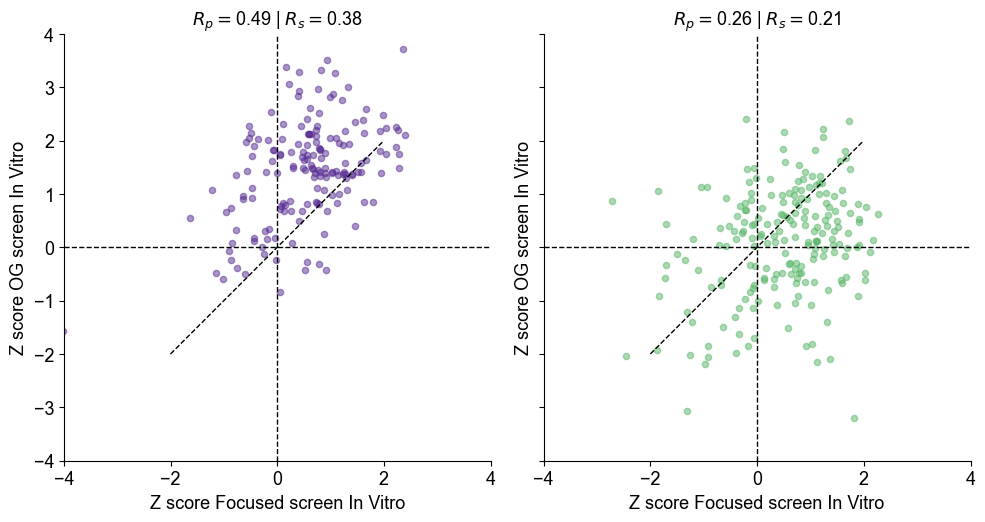

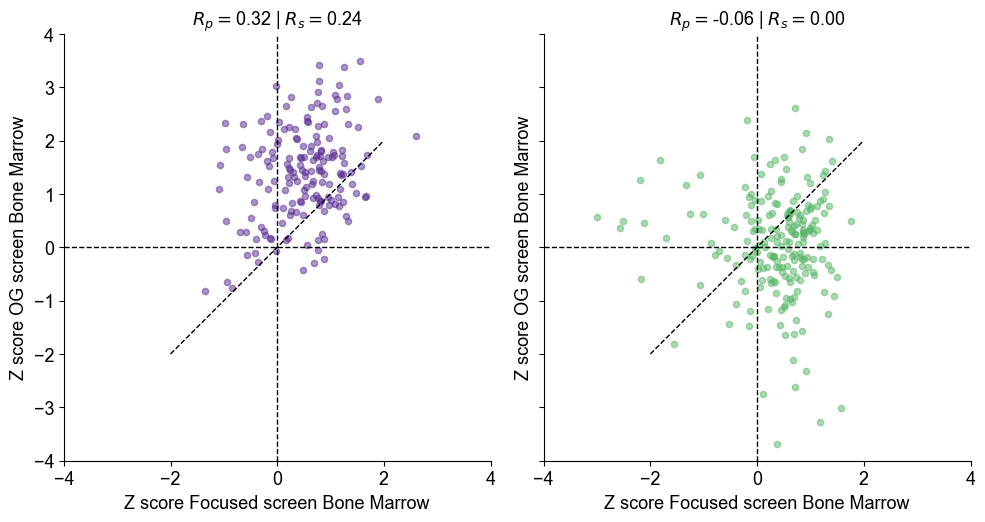

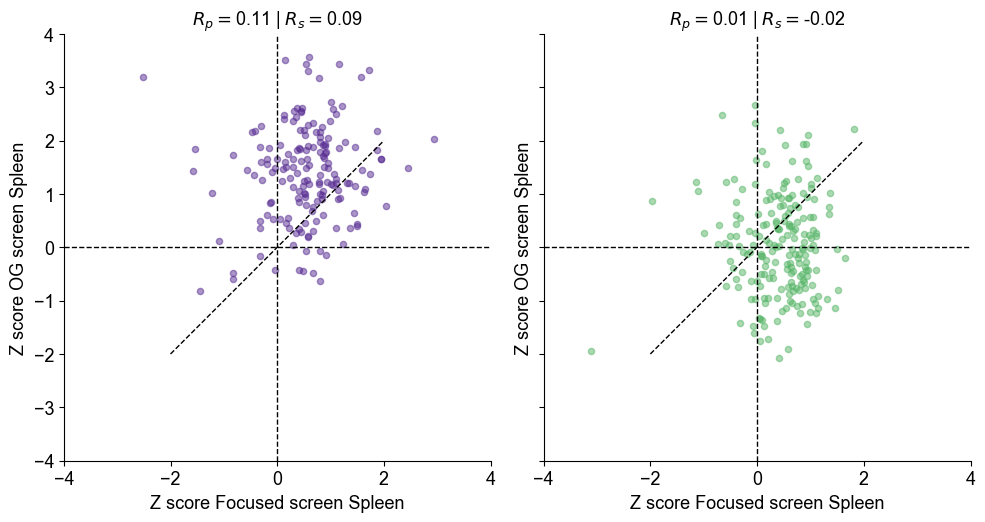

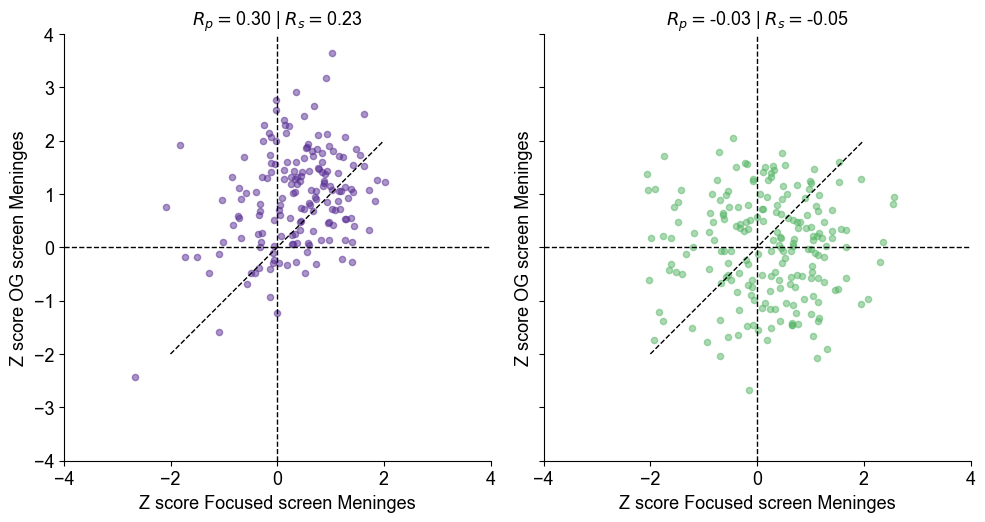

In [63]:
name_dict = dict(zip(['d15','bm','spleen','men'],[
    'In Vitro',
    'Bone Marrow',
    'Spleen','Meninges'
]))
for tissue in ['d15','bm','spleen','men']:
    fig, ax = plt.subplots(1,2, figsize = (10,5), sharey=True, sharex=True)
    for i, (df, name) in enumerate(zip([df_ABE, df_CBE], ['ABE','CBE'])):
        ax[i].set_aspect('equal')
        print(name)
        corr_spearman, p_value_spearman = scipy.stats.spearmanr(df[f'focused_{tissue}'], df[f'og_{tissue}'])
        print("Spearman Correlation Coefficient: {:.4f}".format(corr_spearman))
        print(p_value_spearman)
        corr_pearson, p_value_pearson = scipy.stats.pearsonr(df[f'focused_{tissue}'], df[f'og_{tissue}'])
        print("Pearson Correlation Coefficient: {:.4f}".format(corr_pearson))
        print(p_value_pearson)
        pear = "{:.2f}".format(corr_pearson)
        spear = "{:.2f}".format(corr_spearman)
        ax[i].scatter(df[f'focused_{tissue}'], df[f'og_{tissue}'], color = colors[i], s = 20,alpha = .5)
        ax[i].set_title('$R_{p} = $' + f'{pear}' + ' | $R_{s} = $' + f'{spear}', fontsize=13)
        ax[i].plot([-2,2],[-2,2], linestyle='dashed', color='black', linewidth=1)
        ax[i].axhline(y=0, linestyle='dashed', color='black', linewidth=1)
        ax[i].axvline(x=0, linestyle='dashed', color='black', linewidth=1)
        ax[i].set_xlabel(f'Z score Focused screen {name_dict[tissue]}', fontsize=13)
        ax[i].set_ylabel(f'Z score OG screen {name_dict[tissue]}', fontsize=13)
        ax[i].spines[['top', 'right']].set_visible(False)
        ax[i].tick_params(axis='both', which='major', labelsize=13,)
        ax[i].set_xlim(-4,4)
        ax[i].set_ylim(-4,4)
    fig.tight_layout()
    fig.savefig(f'figures/corr_tissue_scatter_{tissue}.pdf')

In [68]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 100

ABE_targ = LFC_ABE[(LFC_ABE['classification']=='targeting guide')& (LFC_ABE['target_base_edit_perc']>=min_edit) & (LFC_ABE['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

list_guides = []
for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
    cc2['Rank'] = range(1, len(cc2)+1)
    cc2 = cc2[cc2['gene_name_m_corrected']=='Trp53'].reset_index(drop=True)
    cc2['Rank_gene']    = range(1, len(cc2)+1)
    #split by significance level
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    list_guides = list_guides + list(cc3['gRNA_id'])

set(list_guides)

{'gRNA_12523',
 'gRNA_12536',
 'gRNA_12548',
 'gRNA_12556',
 'gRNA_12558',
 'gRNA_12579',
 'gRNA_12580',
 'gRNA_12597',
 'gRNA_12601',
 'gRNA_12602',
 'gRNA_12604'}

In [70]:
LFC_ABE_Trp53 = LFC_ABE[LFC_ABE['gRNA_id'].isin(set(list_guides))]
LFC_ABE_og_Trp53 = LFC_ABE_OG[LFC_ABE_OG['gRNA_id'].isin(set(list_guides))]

In [ ]:
LFC_ABE_Trp53

,gRNA_id,Gene,bm1,bm2,bm3,bm4,bm5,LFC_avg_bm,LFC_median_bm,Input_median,...,p_low_unadjusted_men_stouffers,FDR_high_men_stouffers,FDR_low_men_stouffers,FDR_men_fishers,FDR_men_stouffers,z_score_bm,z_score_d15,z_score_d5,z_score_men,z_score_spleen
153,gRNA_12523,Trp53,0.619946,0.270447,0.783194,0.352657,0.090892,0.423427,0.352657,2341.557463,...,0.806818,0.532083,1.0,0.637623,0.532083,0.522464,0.627408,0.773689,1.042358,0.393072
154,gRNA_12536,Trp53,0.196843,0.172532,0.376304,0.087733,-0.221443,0.122394,0.172532,1564.934478,...,0.945004,0.346456,1.0,0.448806,0.346456,0.359977,1.021566,0.593699,0.562895,0.773532
155,gRNA_12548,Trp53,1.069043,2.125860,-1.784960,0.742888,1.568398,0.744246,1.069043,735.652960,...,0.398418,0.839166,1.0,0.735760,0.839166,1.168700,1.792021,1.220057,0.340256,0.526726
156,gRNA_12556,Trp53,1.206534,1.767857,0.880039,1.508977,1.969257,1.466533,1.508977,1230.908269,...,0.936282,0.375997,1.0,0.379623,0.375997,1.565555,2.258577,2.403814,1.377211,1.943359
157,gRNA_12558,Trp53,1.257135,0.762070,-0.385721,0.707861,0.645855,0.597440,0.707861,2796.565748,...,0.991590,0.195176,1.0,0.379623,0.195176,0.842886,2.224195,1.320645,0.974542,1.496616
159,gRNA_12579,Trp53,0.884458,-1.983678,0.041409,0.172773,-1.101613,-0.397330,0.041409,820.967013,...,0.842305,0.532083,1.0,0.616347,0.532083,0.241694,0.668681,0.033537,0.435714,0.293378
160,gRNA_12580,Trp53,2.446707,0.970943,-0.699013,0.674100,0.261673,0.730882,0.674100,1157.885224,...,0.490228,0.795448,1.0,0.834201,0.795448,0.812431,0.725990,1.591275,-0.112714,1.097342
163,gRNA_12597,Trp53,0.388600,0.960586,0.765012,0.584348,-0.378503,0.464009,0.584348,1486.609429,...,0.966135,0.285879,1.0,0.379623,0.285879,0.731467,0.098758,0.623480,0.543434,0.136110
164,gRNA_12601,Trp53,1.035372,-0.713658,1.045954,0.333183,1.267472,0.593665,1.035372,1345.383341,...,0.879572,0.485321,1.0,0.584310,0.485321,1.138326,1.017387,1.140898,-0.116518,0.921826
165,gRNA_12602,Trp53,-0.461892,1.334154,0.093665,-0.122884,0.555212,0.279651,0.093665,3682.964302,...,0.391604,0.839166,1.0,0.910832,0.839166,0.288834,-0.860060,0.182745,-0.296277,0.347013


In [72]:
LFC_ABE_og_Trp53

,gRNA_id,Gene,spleen1,spleen2,spleen3,spleen4,LFC_avg_spleen,LFC_median_spleen,Input_median,bonemarrow1,...,p_low_unadjusted_meninges_stouffers,FDR_high_meninges_stouffers,FDR_low_meninges_stouffers,FDR_meninges_fishers,FDR_meninges_stouffers,z_score_bonemarrow,z_score_meninges,z_score_d15,z_score_d5,z_score_spleen
944,gRNA_12523,Trp53,0.870743,1.517560,0.742112,0.577753,0.927042,0.806428,735.889417,0.293385,...,0.885447,0.653868,1.000000,0.734340,0.653868,1.330048,0.413223,1.548544,0.349761,0.914172
950,gRNA_12536,Trp53,0.972968,1.414882,1.244107,0.968140,1.150024,1.108537,672.517570,-0.089073,...,0.296573,1.000000,0.839074,0.812656,0.839074,0.663619,-0.088560,0.986069,-0.127096,1.228845
954,gRNA_12548,Trp53,2.672918,2.200767,0.135401,1.710064,1.679788,1.955415,237.085733,0.606820,...,0.576733,1.000000,0.978921,0.980257,0.978921,1.098913,0.239388,0.856667,1.343555,2.110940
956,gRNA_12556,Trp53,2.125549,1.734555,1.313229,1.311750,1.621271,1.523892,280.819994,0.293635,...,0.859932,0.683349,1.000000,0.821088,0.683349,1.520657,1.084304,2.204326,2.006177,1.661472
958,gRNA_12558,Trp53,0.153952,0.463409,-1.011386,0.456067,0.015511,0.305010,853.053357,0.417487,...,0.808651,0.771798,1.000000,0.854903,0.771798,0.251574,0.469064,1.884209,0.987130,0.391903
966,gRNA_12579,Trp53,1.606878,1.424729,0.428378,1.684037,1.286006,1.515804,128.504833,0.670978,...,0.842091,0.720540,1.000000,0.672088,0.720540,0.612866,1.233937,1.736090,1.246811,1.653047
967,gRNA_12580,Trp53,1.709711,0.644887,1.515300,0.538584,1.102120,1.080094,363.684911,0.539893,...,0.934384,0.543947,1.000000,0.510889,0.543947,0.872669,2.060741,1.972354,1.255245,1.199218
982,gRNA_12597,Trp53,2.740128,3.496679,1.866798,0.324459,2.107016,2.303463,200.256881,1.042220,...,0.993719,0.163890,1.000000,0.240797,0.163890,2.077373,1.862364,2.303135,1.831045,2.473461
986,gRNA_12601,Trp53,0.729925,1.888935,2.816113,1.392314,1.706822,1.640625,336.258785,0.594937,...,0.960370,0.457060,1.000000,0.543309,0.457060,0.933579,1.402302,1.390626,1.174106,1.783059
987,gRNA_12602,Trp53,0.192916,0.168445,-0.328166,0.391267,0.106115,0.180680,1338.364161,1.158686,...,0.714516,0.914622,1.000000,0.757136,0.914622,1.410330,0.099660,-0.246278,-0.416933,0.262404


In [77]:
LIB['HGVSp_m']

0       Non-coding
1           E1060K
2            P592L
3            A737T
4            D323G
           ...    
1628           NaN
1629           NaN
1630           NaN
1631           NaN
1632           NaN
Name: HGVSp_m, Length: 1633, dtype: object

In [92]:
name_dict

{'d15': 'In Vitro', 'bm': 'Bone Marrow', 'spleen': 'Spleen', 'men': 'Meninges'}

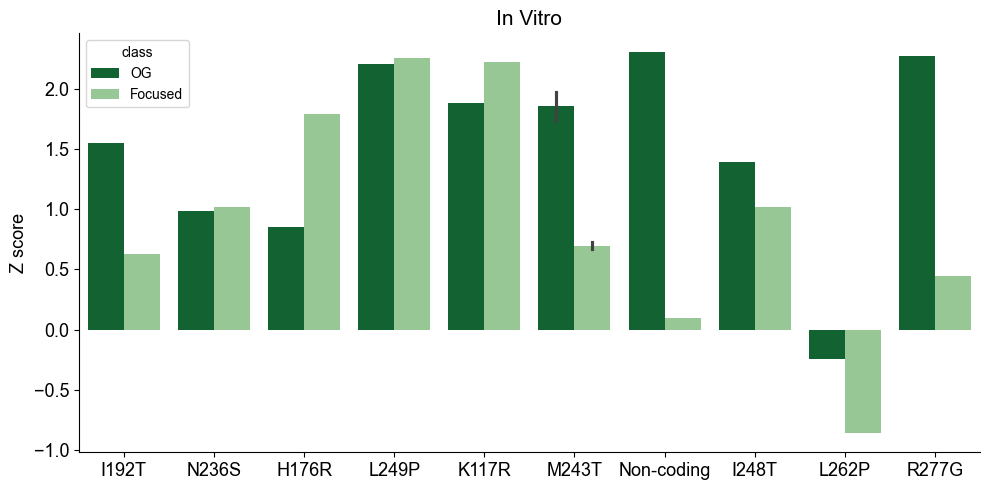

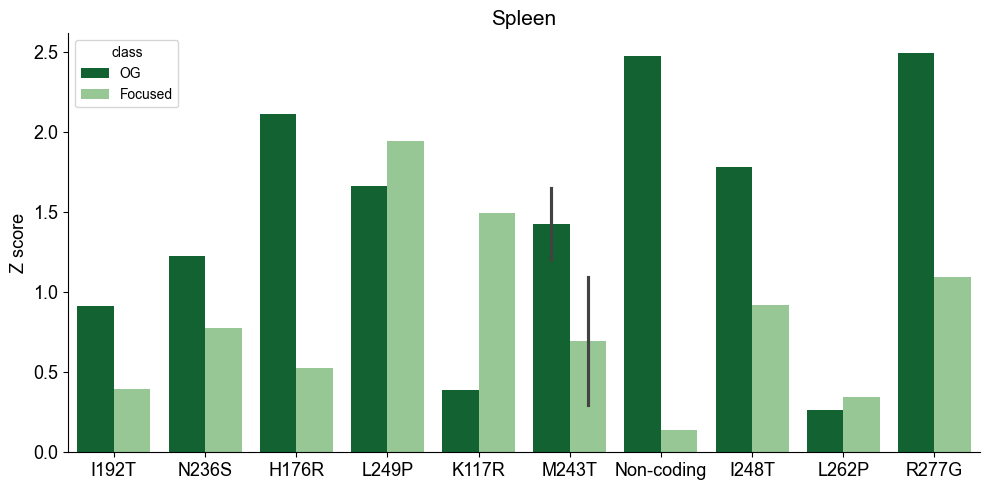

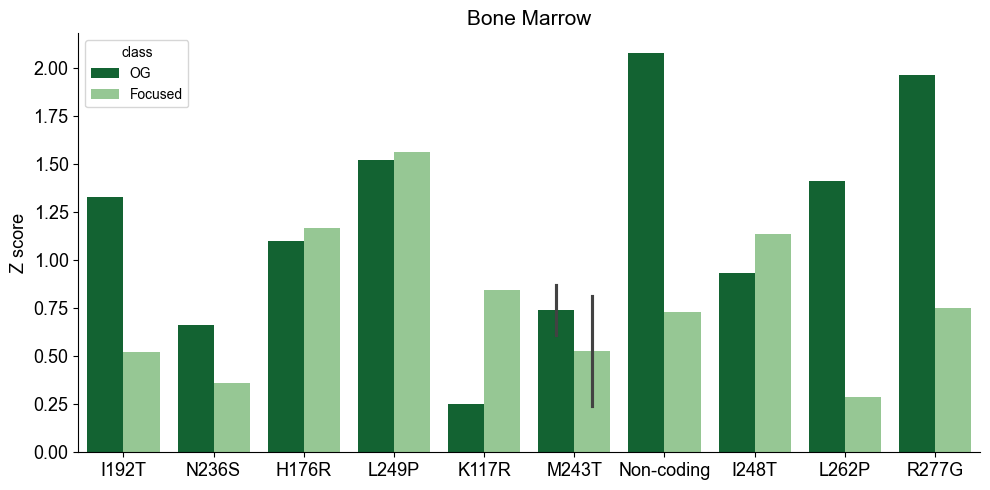

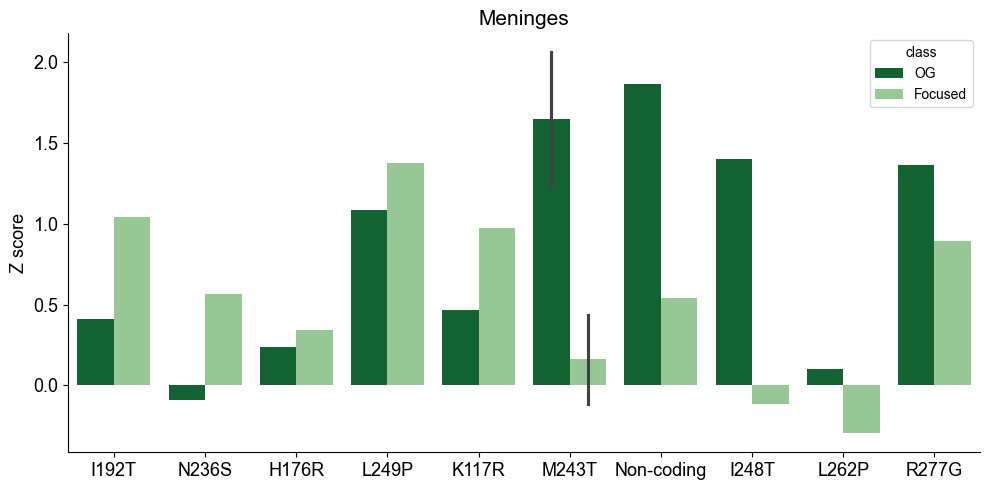

In [96]:
names2 = ['d15','spleen', 'bm', 'men',]
names22 = ['d15','spleen', 'bonemarrow', 'meninges',]

for k, val in enumerate(names2):
    fig, ax = plt.subplots(1,1, figsize = (10,5))
    df_og = LFC_ABE_og_Trp53[['gRNA_id', f'z_score_{names22[k]}']]
    df_og.columns = ['gRNA_id', 'z_score']
    df_og['class'] = 'OG'
    df_focused = LFC_ABE_Trp53[['gRNA_id', f'z_score_{val}']]
    df_focused.columns = ['gRNA_id', 'z_score']
    df_focused['class'] = 'Focused'
    df_plot = pd.concat([df_og, df_focused])
    df_plot = pd.merge(df_plot, LIB[['gRNA_id','HGVSp_m']])
    sns.barplot(x='HGVSp_m', y='z_score', hue='class', data=df_plot, palette=[greens[5], greens[2]])

    ax.set_xlabel('', fontsize=13)
    ax.set_ylabel(f'Z score', fontsize=13)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13,)
    plt.title(f'{name_dict[val]}',fontsize = 15)
    plt.tight_layout()
    plt.savefig(f'figures/p53_bars_{val}.pdf')